In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("data/raw/archive/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [11]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [12]:
df["TotalCharges"].dtype

dtype('float64')

In [13]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [14]:
df = df.dropna()

In [15]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [16]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [17]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [18]:
df["Churn"]

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7032, dtype: int64

In [19]:
{"Yes": 1, "No": 0}

{'Yes': 1, 'No': 0}

In [20]:
df["Churn"].head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [21]:
df = pd.get_dummies(df, drop_first=True)

In [22]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False


In [23]:
df = pd.get_dummies(df, drop_first=True)

In [24]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False


In [25]:
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Columns: 7062 entries, SeniorCitizen to PaymentMethod_Mailed check
dtypes: bool(7057), float64(2), int64(3)
memory usage: 47.6 MB


In [26]:
df = pd.read_csv("data/raw/archive/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [27]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [28]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [29]:
df = df.drop("customerID", axis=1)

In [30]:
df = pd.get_dummies(df, drop_first=True)

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   Churn                                  7043 non-null   int64  
 5   gender_Male                            7043 non-null   bool   
 6   Partner_Yes                            7043 non-null   bool   
 7   Dependents_Yes                         7043 non-null   bool   
 8   PhoneService_Yes                       7043 non-null   bool   
 9   MultipleLines_No phone service         7043 non-null   bool   
 10  MultipleLines_Yes                      7043 non-null   bool   
 11  InternetService

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

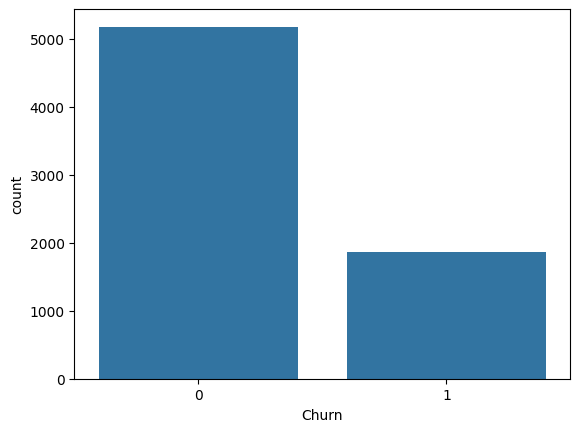

In [34]:
sns.countplot(x="Churn", data=df)
plt.show()

In [35]:
df_raw = pd.read_csv("data/raw/archive/WA_Fn-UseC_-Telco-Customer-Churn.csv")

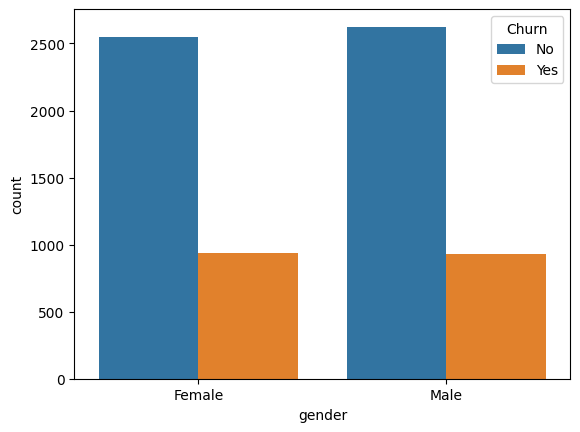

In [36]:
sns.countplot(x="gender", hue="Churn", data=df_raw)
plt.show()

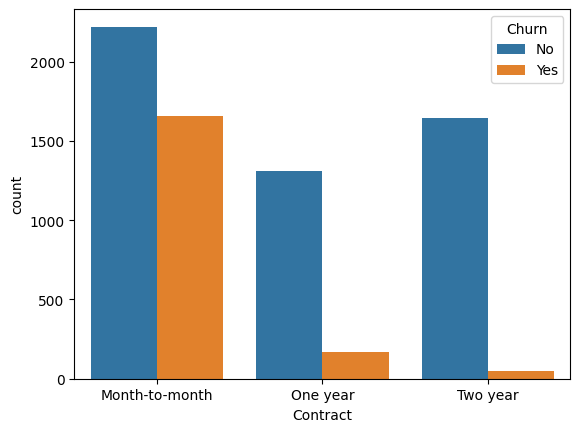

In [37]:
sns.countplot(x="Contract", hue="Churn", data=df_raw)
plt.show()

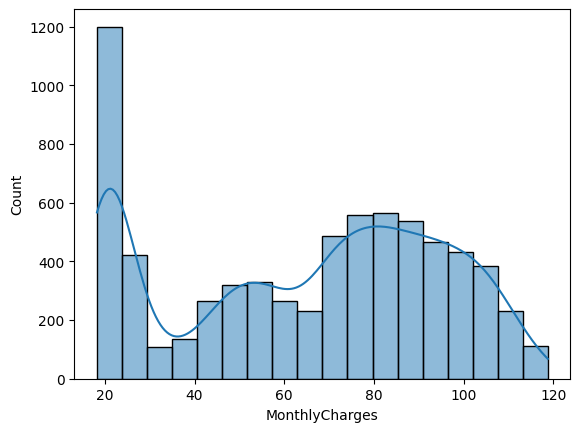

In [38]:
sns.histplot(df_raw["MonthlyCharges"], kde=True)
plt.show()

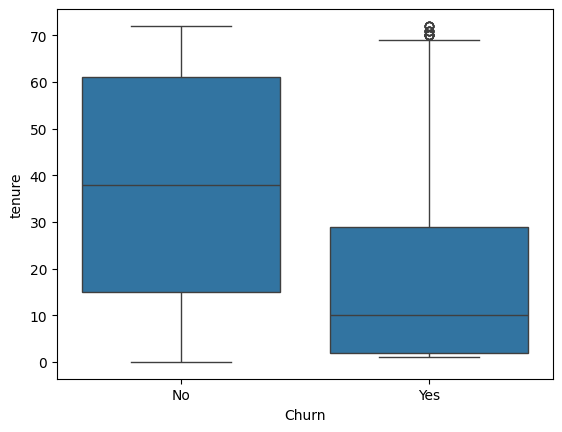

In [39]:
sns.boxplot(x="Churn", y="tenure", data=df_raw)

plt.show()

Customers who churned generally have lower tenure compared to customers who did not churn. This suggests that newer customers are more likely to leave the company.

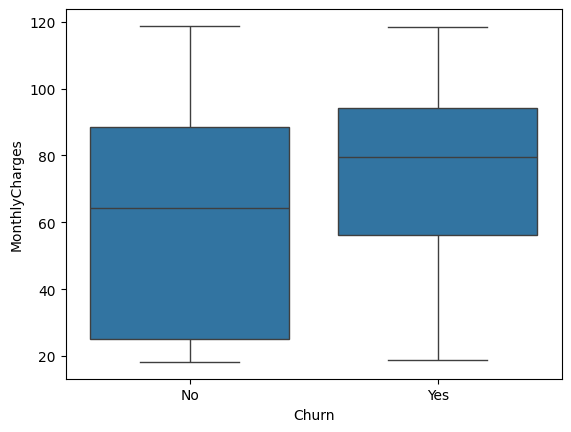

In [40]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df_raw)

plt.show()

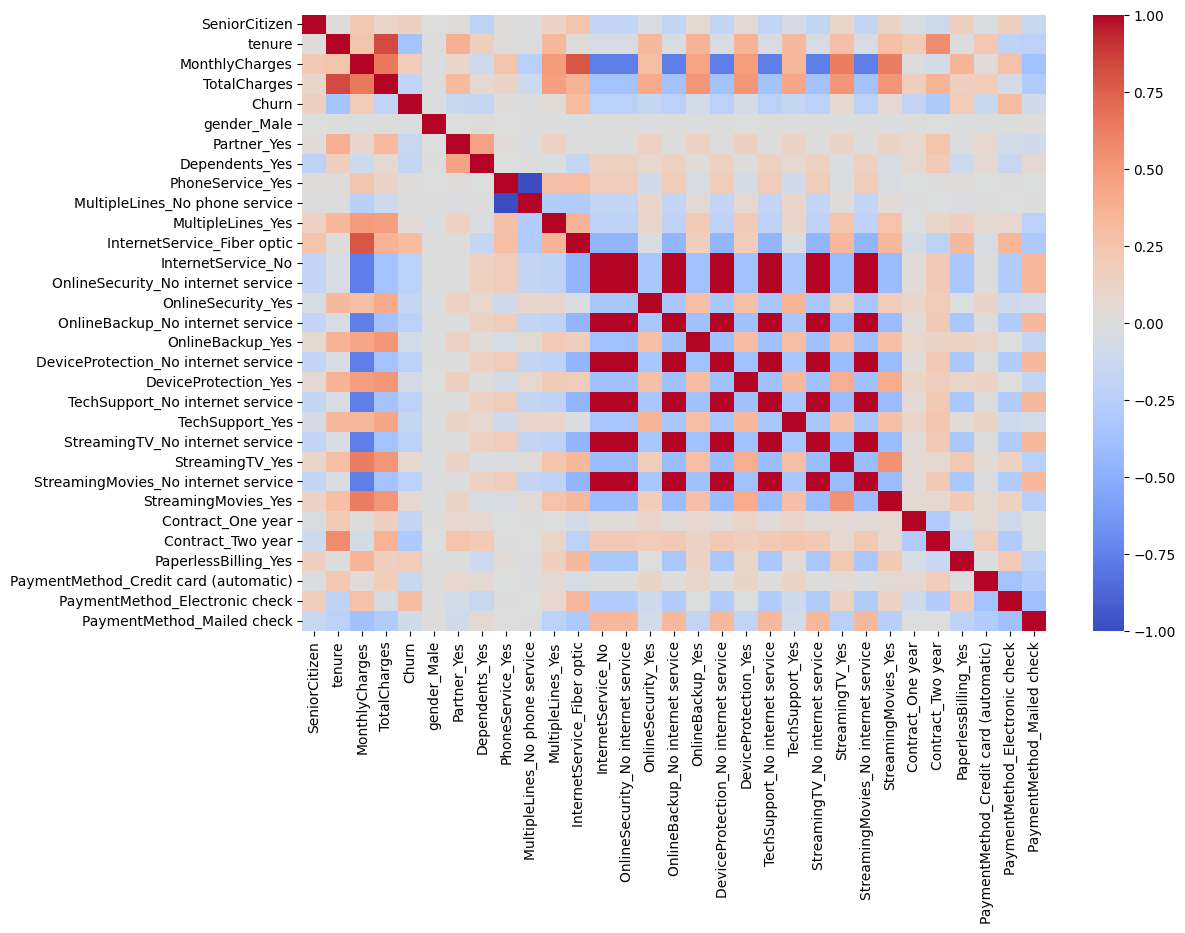

In [41]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.show()

In [42]:
df.corr()["Churn"].sort_values(ascending=False)

Churn                                    1.000000
InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
MonthlyCharges                           0.193356
PaperlessBilling_Yes                     0.191825
SeniorCitizen                            0.150889
StreamingTV_Yes                          0.063228
StreamingMovies_Yes                      0.061382
MultipleLines_Yes                        0.040102
PhoneService_Yes                         0.011942
gender_Male                             -0.008612
MultipleLines_No phone service          -0.011942
DeviceProtection_Yes                    -0.066160
OnlineBackup_Yes                        -0.082255
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Partner_Yes                             -0.150448
Dependents_Yes                          -0.164221
TechSupport_Yes                         -0.164674
OnlineSecurity_Yes                      -0.171226


The strongest negative relationship with churn is tenure.
Fiber optic service, electronic check payment, and higher monthly charges are positively related to churn.

In [43]:
df_raw[["MonthlyCharges", "TotalCharges", "tenure"]].info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   MonthlyCharges  7043 non-null   float64
 1   TotalCharges    7043 non-null   str    
 2   tenure          7043 non-null   int64  
dtypes: float64(1), int64(1), str(1)
memory usage: 165.2 KB


In [44]:
df_raw["TotalCharges"] = pd.to_numeric(df_raw["TotalCharges"], errors="coerce")

In [45]:
df_raw[["MonthlyCharges", "TotalCharges", "tenure"]].info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   MonthlyCharges  7043 non-null   float64
 1   TotalCharges    7032 non-null   float64
 2   tenure          7043 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 165.2 KB


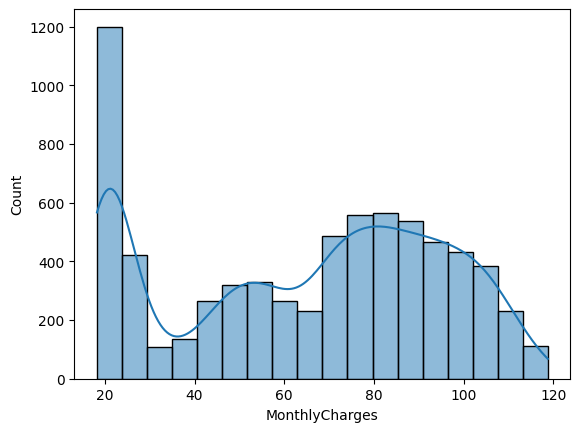

In [46]:
sns.histplot(df_raw["MonthlyCharges"], kde=True)
plt.show()

The MonthlyCharges distribution appears bimodal, with one group of customers having low monthly charges and another group having higher monthly charges. Most customers are concentrated around 20–30 and 70–100 monthly charges.

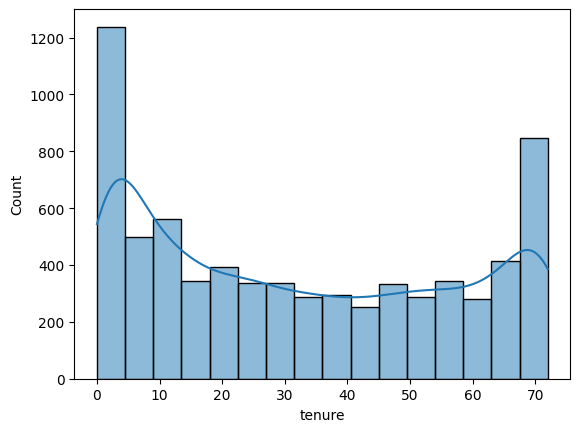

In [47]:
sns.histplot(df_raw["tenure"], kde=True)
plt.show()

The tenure distribution shows two major customer groups:
new customers with low tenure and loyal long-term customers with high tenure.
Many customers are concentrated around the first few months and around 70 months.

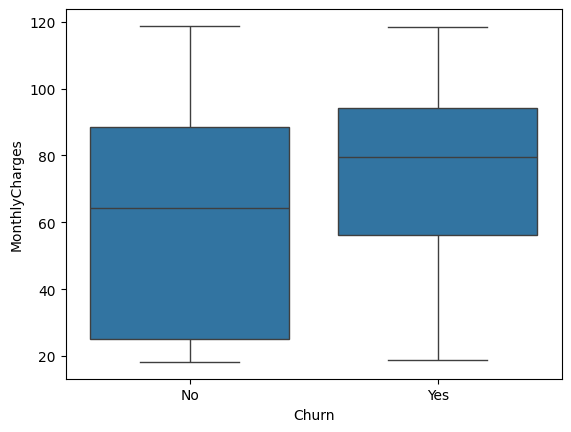

In [48]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df_raw)
plt.show()

Customers with higher monthly bills are more likely to churn.

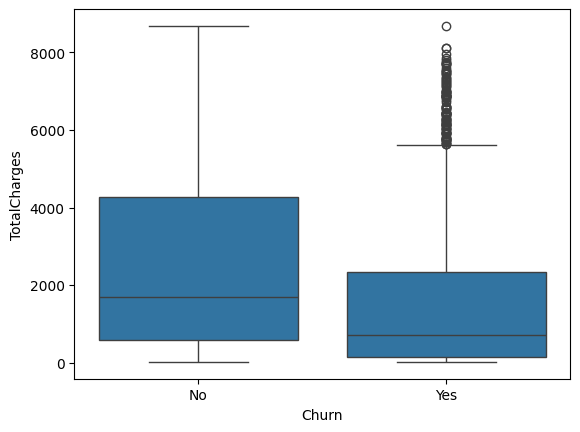

In [49]:
sns.boxplot(x="Churn", y="TotalCharges", data=df_raw)
plt.show()

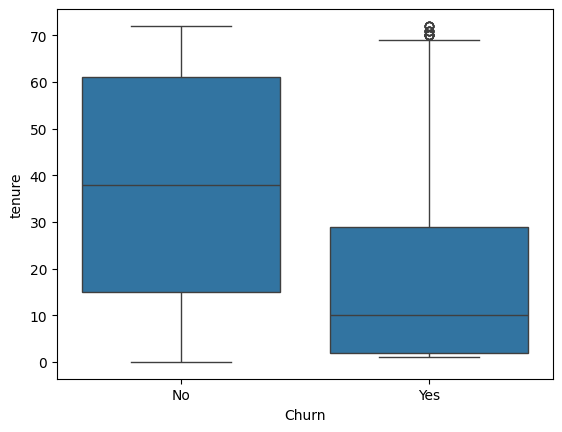

In [50]:
sns.boxplot(x="Churn", y="tenure", data=df_raw)
plt.show()

Customers with higher MonthlyCharges seem more likely to churn.

In [51]:
df.corr()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
SeniorCitizen,1.000000,0.016567,0.220173,0.102411,0.150889,-0.001874,0.016479,-0.211185,0.008576,-0.008576,...,-0.182742,0.105378,-0.182742,0.120176,-0.046262,-0.117000,0.156530,-0.024135,0.171718,-0.153477
tenure,0.016567,1.000000,0.247900,0.825880,-0.352229,0.005106,0.379697,0.159712,0.008448,-0.008448,...,-0.039062,0.279756,-0.039062,0.286111,0.202570,0.558533,0.006152,0.233006,-0.208363,-0.233852
MonthlyCharges,0.220173,0.247900,1.000000,0.651065,0.193356,-0.014569,0.096848,-0.113890,0.247398,-0.247398,...,-0.763557,0.629603,-0.763557,0.627429,0.004904,-0.074681,0.352150,0.030550,0.271625,-0.377437
TotalCharges,0.102411,0.825880,0.651065,1.000000,-0.199484,0.000048,0.319072,0.064653,0.113008,-0.113008,...,-0.374878,0.515709,-0.374878,0.519867,0.170569,0.358036,0.157830,0.182663,-0.060436,-0.294708
Churn,0.150889,-0.352229,0.193356,-0.199484,1.000000,-0.008612,-0.150448,-0.164221,0.011942,-0.011942,...,-0.227890,0.063228,-0.227890,0.061382,-0.177820,-0.302253,0.191825,-0.134302,0.301919,-0.091683
gender_Male,-0.001874,0.005106,-0.014569,0.000048,-0.008612,1.000000,-0.001808,0.010517,-0.006488,0.006488,...,0.006026,-0.008393,0.006026,-0.010487,0.008026,-0.003695,-0.011754,0.001215,0.000752,0.013744
Partner_Yes,0.016479,0.379697,0.096848,0.319072,-0.150448,-0.001808,1.000000,0.452676,0.017706,-0.017706,...,0.000615,0.124666,0.000615,0.117412,0.082783,0.248091,-0.014877,0.082029,-0.083852,-0.095125
Dependents_Yes,-0.211185,0.159712,-0.113890,0.064653,-0.164221,0.010517,0.452676,1.000000,-0.001762,0.001762,...,0.139812,-0.016558,0.139812,-0.039741,0.068368,0.204613,-0.111377,0.060267,-0.150642,0.059071
PhoneService_Yes,0.008576,0.008448,0.247398,0.113008,0.011942,-0.006488,0.017706,-0.001762,1.000000,-1.000000,...,0.172209,-0.022574,0.172209,-0.032959,-0.002791,0.003519,0.016505,-0.007721,0.003062,-0.003319
MultipleLines_No phone service,-0.008576,-0.008448,-0.247398,-0.113008,-0.011942,0.006488,-0.017706,0.001762,-1.000000,1.000000,...,-0.172209,0.022574,-0.172209,0.032959,0.002791,-0.003519,-0.016505,0.007721,-0.003062,0.003319


In [52]:
df.corr()["Churn"].sort_values(ascending=False)

Churn                                    1.000000
InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
MonthlyCharges                           0.193356
PaperlessBilling_Yes                     0.191825
SeniorCitizen                            0.150889
StreamingTV_Yes                          0.063228
StreamingMovies_Yes                      0.061382
MultipleLines_Yes                        0.040102
PhoneService_Yes                         0.011942
gender_Male                             -0.008612
MultipleLines_No phone service          -0.011942
DeviceProtection_Yes                    -0.066160
OnlineBackup_Yes                        -0.082255
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Partner_Yes                             -0.150448
Dependents_Yes                          -0.164221
TechSupport_Yes                         -0.164674
OnlineSecurity_Yes                      -0.171226


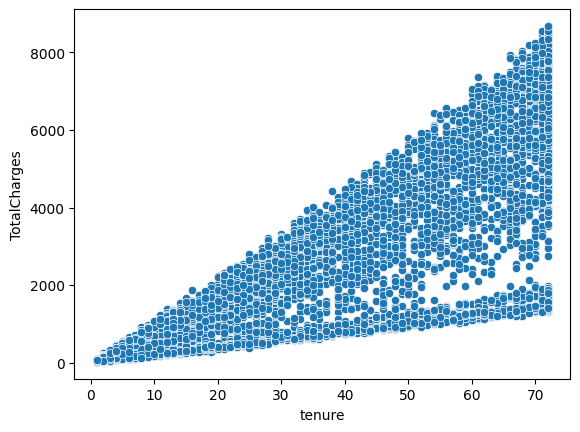

In [53]:
sns.scatterplot(x="tenure", y="TotalCharges", data=df_raw)

plt.show()

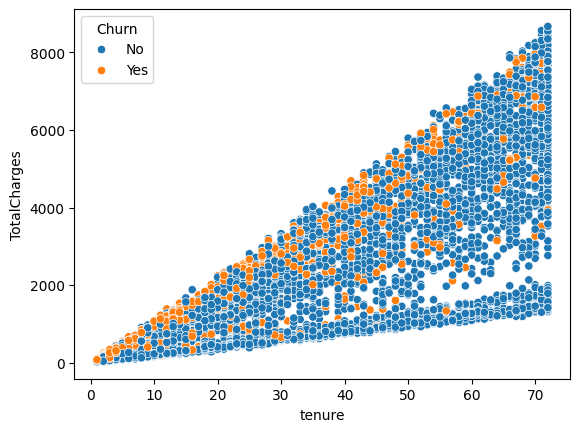

In [54]:
sns.scatterplot(
    x="tenure",
    y="TotalCharges",
    hue="Churn",
    data=df_raw
)

plt.show()

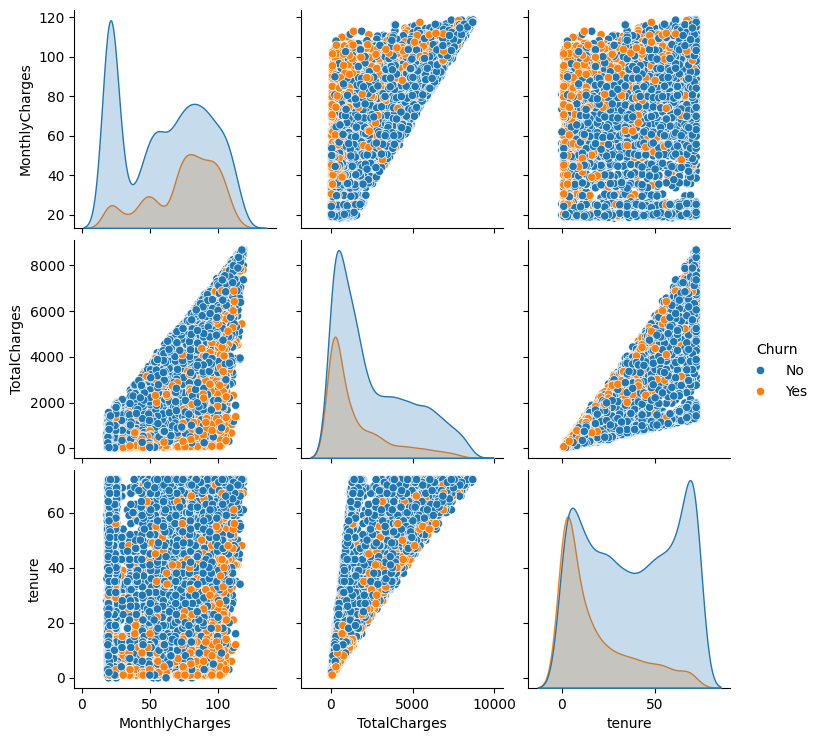

In [55]:
sns.pairplot(
    df_raw[["MonthlyCharges", "TotalCharges", "tenure", "Churn"]],
    hue="Churn"
)

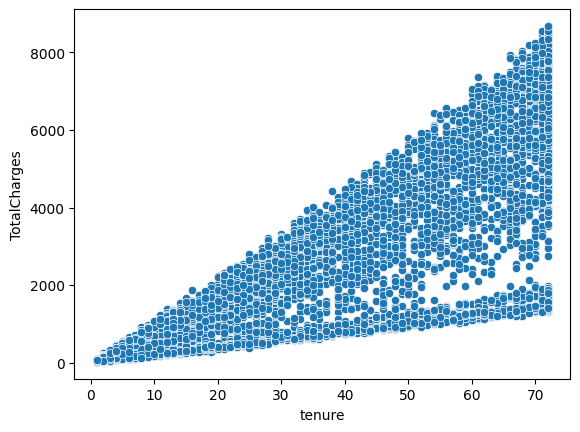

In [56]:
sns.scatterplot(x="tenure", y="TotalCharges", data=df_raw)

plt.show()

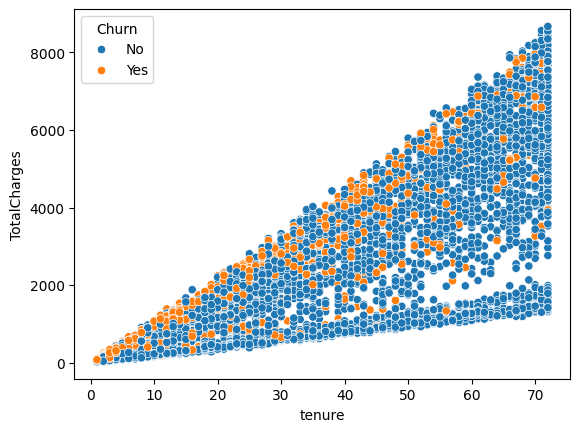

In [57]:
sns.scatterplot(
    x="tenure",
    y="TotalCharges",
    hue="Churn",
    data=df_raw
)

plt.show()

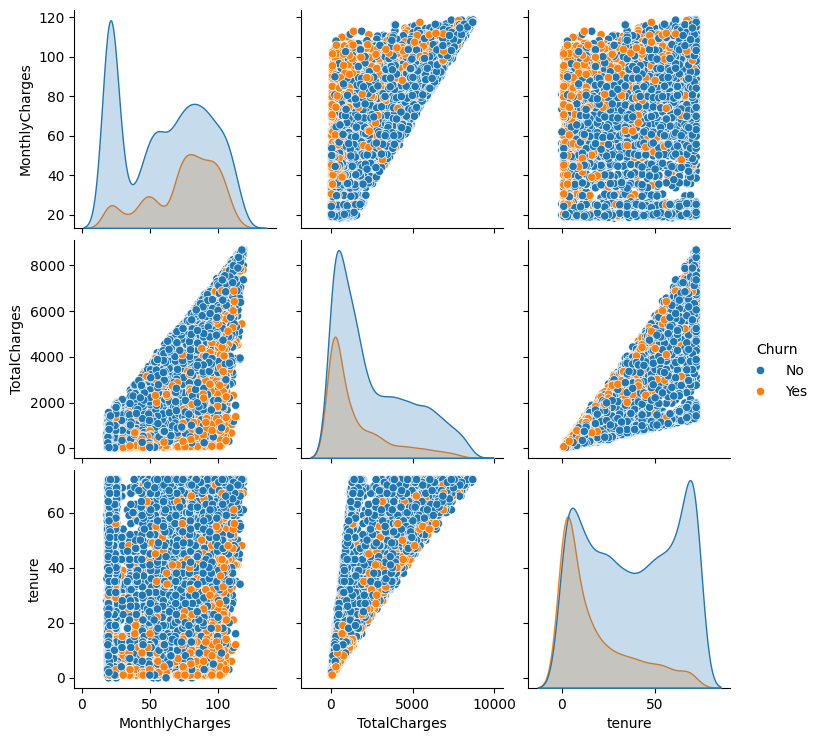

In [58]:
sns.pairplot(
    df_raw[["MonthlyCharges", "TotalCharges", "tenure", "Churn"]],
    hue="Churn"
)

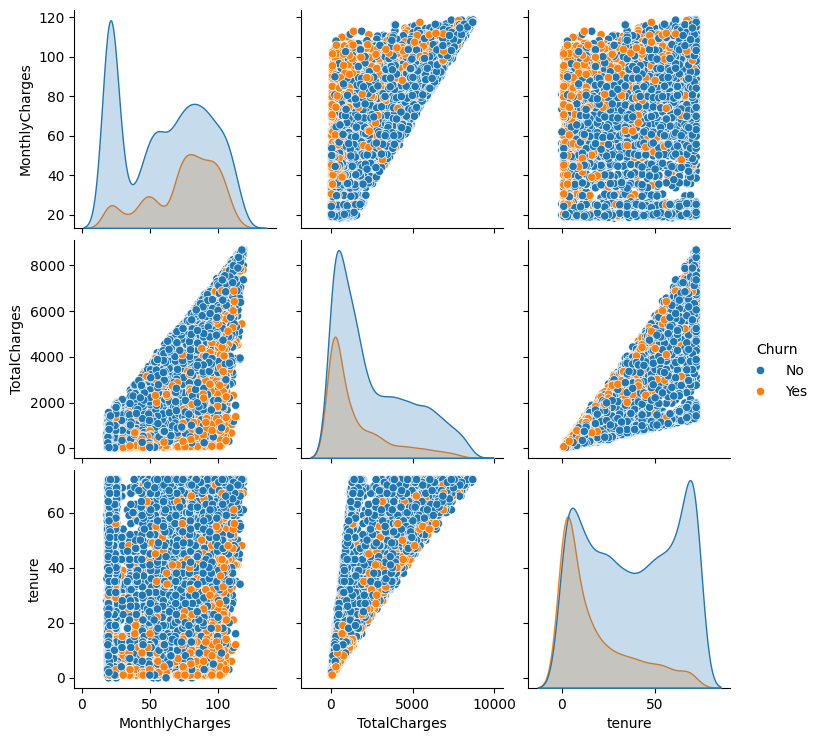

In [59]:
sns.pairplot(
    df_raw[["MonthlyCharges", "TotalCharges", "tenure", "Churn"]],
    hue="Churn"
)

<Axes: xlabel='tenure', ylabel='TotalCharges'>

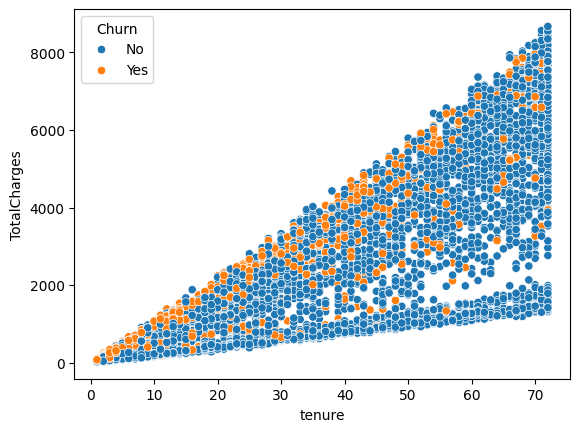

In [60]:
sns.scatterplot(
    x="tenure",
    y="TotalCharges",
    hue="Churn",
    data=df_raw
)

<Axes: >

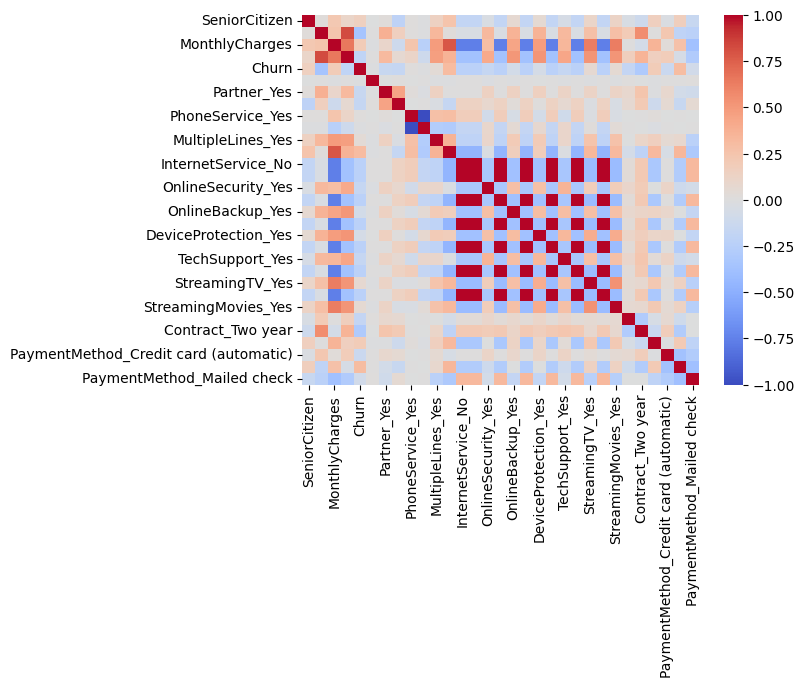

In [61]:
sns.heatmap(df.corr(), cmap="coolwarm")

In [62]:
df_raw.groupby("Contract")["Churn"].value_counts(normalize=True)

Contract        Churn
Month-to-month  No       0.572903
                Yes      0.427097
One year        No       0.887305
                Yes      0.112695
Two year        No       0.971681
                Yes      0.028319
Name: proportion, dtype: float64

In [63]:
df_corr = df_raw.copy()

df_corr["Churn"] = df_corr["Churn"].map({"No": 0, "Yes": 1})

In [64]:
df_corr[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]].corr()

,tenure,MonthlyCharges,TotalCharges,Churn
tenure,1.000000,0.247900,0.825880,-0.352229
MonthlyCharges,0.247900,1.000000,0.651065,0.193356
TotalCharges,0.825880,0.651065,1.000000,-0.199484
Churn,-0.352229,0.193356,-0.199484,1.000000


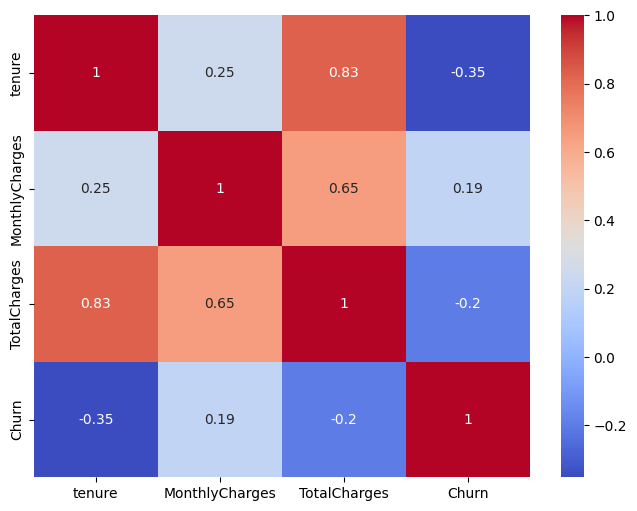

In [65]:
corr_matrix = df_corr[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()

In [66]:
corr_matrix["Churn"].sort_values(ascending=False)

Churn             1.000000
MonthlyCharges    0.193356
TotalCharges     -0.199484
tenure           -0.352229
Name: Churn, dtype: float64

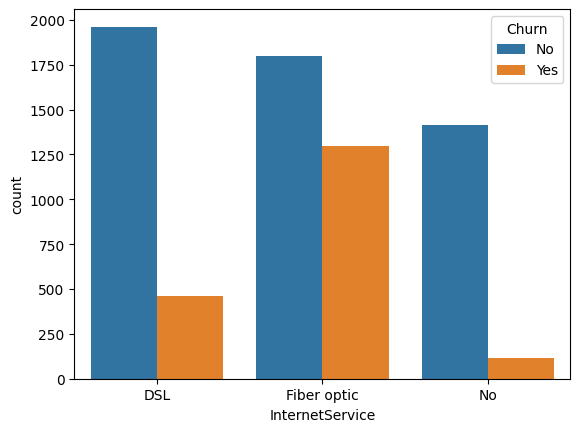

In [67]:
sns.countplot(x="InternetService", hue="Churn", data=df_raw)
plt.show()

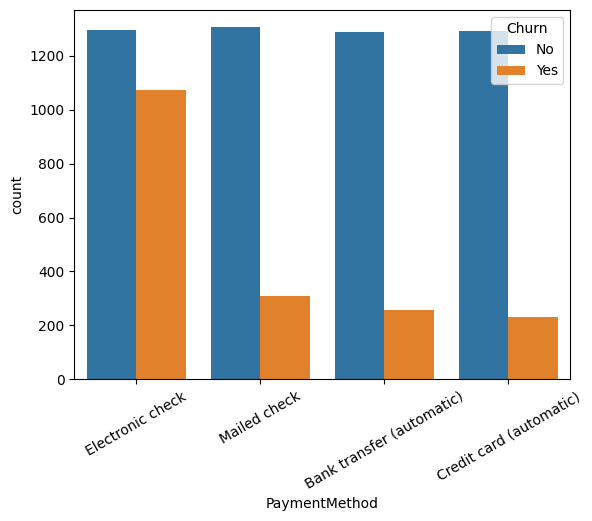

In [68]:
sns.countplot(x="PaymentMethod", hue="Churn", data=df_raw)
plt.xticks(rotation=30)
plt.show()

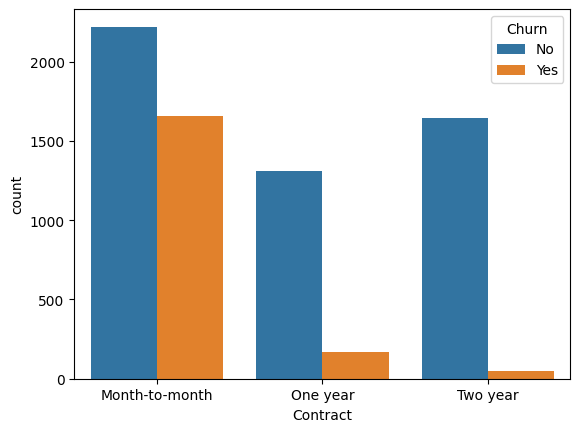

In [69]:
sns.countplot(x="Contract", hue="Churn", data=df_raw)
plt.show()

In [70]:
df_raw.groupby("Contract")["Churn"].value_counts(normalize=True)

Contract        Churn
Month-to-month  No       0.572903
                Yes      0.427097
One year        No       0.887305
                Yes      0.112695
Two year        No       0.971681
                Yes      0.028319
Name: proportion, dtype: float64

Customers with month-to-month contracts have the highest churn rate.

Customers with one-year and two-year contracts are more likely to stay with the company.

Long-term contracts appear to reduce customer churn.

In [71]:
df_raw.groupby("InternetService")["Churn"].value_counts(normalize=True)

InternetService  Churn
DSL              No       0.810409
                 Yes      0.189591
Fiber optic      No       0.581072
                 Yes      0.418928
No               No       0.925950
                 Yes      0.074050
Name: proportion, dtype: float64

Customers using Fiber optic have the highest churn rate.

Customers without internet service have the lowest churn rate.

In [72]:
df_raw.groupby("PaymentMethod")["Churn"].value_counts(normalize=True)

PaymentMethod              Churn
Bank transfer (automatic)  No       0.832902
                           Yes      0.167098
Credit card (automatic)    No       0.847569
                           Yes      0.152431
Electronic check           No       0.547146
                           Yes      0.452854
Mailed check               No       0.808933
                           Yes      0.191067
Name: proportion, dtype: float64

Customers using electronic checks have the highest churn rate.

Customers using automatic payment methods are less likely to churn.

In [73]:
df_ml = df_raw.copy()

In [74]:
df_ml["TotalCharges"] = pd.to_numeric(df_ml["TotalCharges"], errors="coerce")

In [75]:
df_ml.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [76]:
df_ml = df_ml.drop("customerID", axis=1)

In [77]:
df_ml = df_raw.copy()

In [78]:
df_ml["TotalCharges"] = pd.to_numeric(
    df_ml["TotalCharges"],
    errors="coerce"
)

In [79]:
df_ml.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [80]:
df_ml = df_ml.dropna()

In [81]:
df_ml.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [82]:
df_ml = df_ml.drop("customerID", axis=1)

In [83]:
df_ml["Churn"] = df_ml["Churn"].map(
    {"No":0,"Yes":1}
)

In [84]:
df_ml = pd.get_dummies(df_ml, drop_first=True)

In [85]:
df_ml.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [86]:
X = df_ml.drop("Churn", axis=1)

y = df_ml["Churn"]

In [87]:
X.shape

(7032, 30)

In [88]:
y.shape

(7032,)

In [89]:
from sklearn.model_selection import train_test_split

In [90]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [91]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [92]:
X_train.shape

(5625, 30)

In [93]:
X_test.shape

(1407, 30)

In [94]:
y_train.shape

(5625,)

In [95]:
y_test.shape

(1407,)

In [96]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [97]:
X_train_scaled.shape

(5625, 30)

In [98]:
X_test_scaled.shape

(1407, 30)

In [99]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [100]:
y_pred = model.predict(X_test_scaled)

In [101]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7874911158493249


In [102]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[915 118]
 [181 193]]


In [103]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



# Stage 6 — Model Evaluation and Comparison


In [104]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier

In [105]:
rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [106]:
print("Random Forest Accuracy:")
print(accuracy_score(y_test, y_pred_rf))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy:
0.7853589196872779
Confusion Matrix:
[[927 106]
 [196 178]]
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.48      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



In [107]:
y_pred

array([0, 0, 1, ..., 0, 0, 0], shape=(1407,))

In [108]:
y_pred_rf

array([0, 0, 1, ..., 0, 0, 0], shape=(1407,))

In [109]:
from sklearn.metrics import precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision_Churn": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall_Churn": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_rf)
    ],
    "F1_Churn": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_rf)
    ]
})

comparison

,Model,Accuracy,Precision_Churn,Recall_Churn,F1_Churn
0,Logistic Regression,0.787491,0.620579,0.516043,0.563504
1,Random Forest,0.785359,0.626761,0.475936,0.541033


### Model Comparison Conclusion

Both models achieved similar accuracy (~78%).

Random Forest showed slightly higher precision, meaning it was slightly more accurate when predicting churn customers.

However, Logistic Regression achieved higher recall and F1-score for churn prediction.

Since customer churn detection focuses on identifying customers before they leave, recall is especially important.

For this project, Logistic Regression currently performs better as the preferred model.

In [110]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({

    "Feature": X.columns,
    "Importance": rf_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
3,TotalCharges,0.193409
2,MonthlyCharges,0.169758
1,tenure,0.167572
10,InternetService_Fiber optic,0.039999
28,PaymentMethod_Electronic check,0.035016
13,OnlineSecurity_Yes,0.028905
25,Contract_Two year,0.028618
4,gender_Male,0.026971
19,TechSupport_Yes,0.025829
26,PaperlessBilling_Yes,0.025044


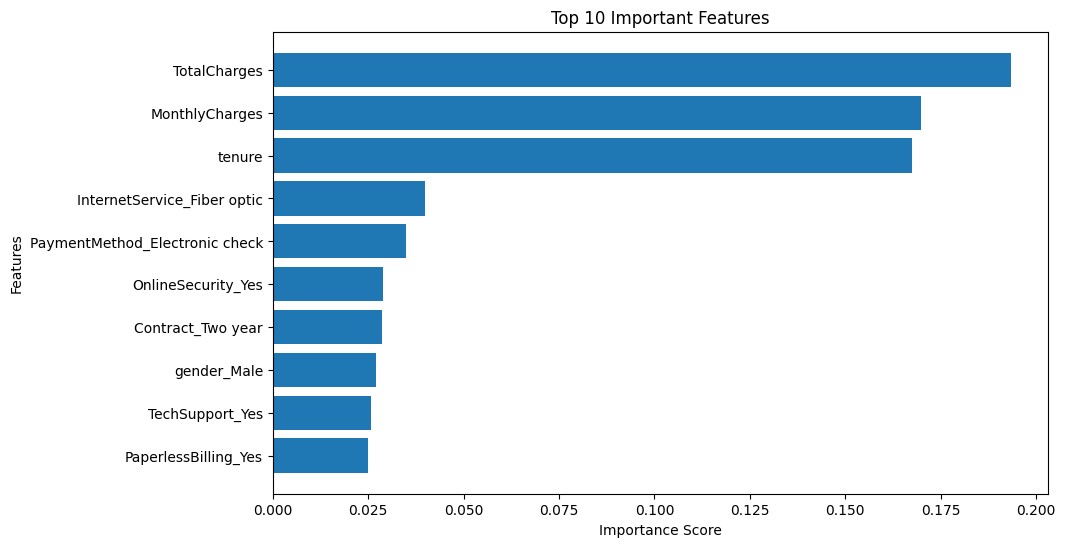

In [111]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

### Feature Importance Conclusion

The Random Forest model identified TotalCharges, MonthlyCharges, and tenure as the most influential features for churn prediction.

The results are consistent with the exploratory analysis performed earlier, where customer duration and payment-related variables showed strong relationships with churn behavior.

Internet service type and payment method also contributed to churn prediction.

In [112]:
from sklearn.metrics import classification_report

# Get probability predictions
y_prob = model.predict_proba(X_test_scaled)[:,1]

# Change prediction threshold
threshold = 0.35

y_pred_new = (y_prob >= threshold).astype(int)

print(classification_report(
    y_test,
    y_pred_new
))


              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1033
           1       0.54      0.71      0.61       374

    accuracy                           0.76      1407
   macro avg       0.71      0.74      0.72      1407
weighted avg       0.79      0.76      0.77      1407



Stage 6.6 — Recall Improvement

In [113]:
from sklearn.metrics import classification_report

# Get probability predictions
y_prob = model.predict_proba(X_test_scaled)[:,1]

# Change prediction threshold
threshold = 0.35

y_pred_new = (y_prob >= threshold).astype(int)

print(classification_report(
    y_test,
    y_pred_new
))

              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1033
           1       0.54      0.71      0.61       374

    accuracy                           0.76      1407
   macro avg       0.71      0.74      0.72      1407
weighted avg       0.79      0.76      0.77      1407



Stage 6.7 — ROC Curve and AUC

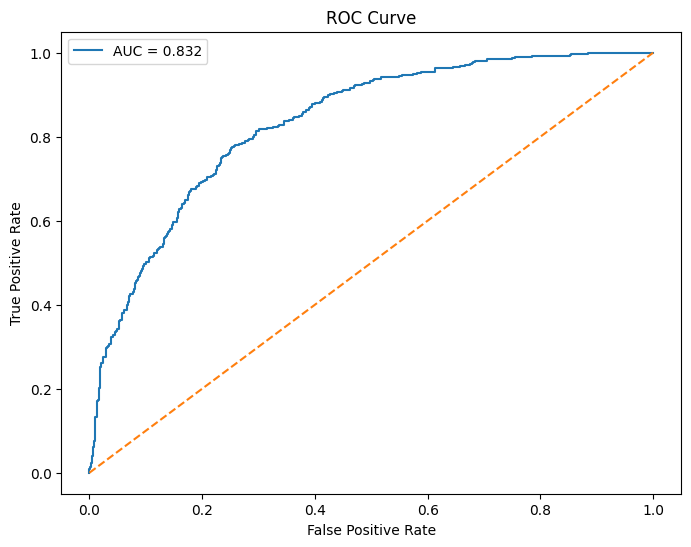

AUC Score: 0.8319235288940887


In [114]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

# Calculate AUC score
auc_score = roc_auc_score(
    y_test,
    y_prob
)

# Create figure
plt.figure(figsize=(8,6))

# Draw ROC curve
plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.3f}"
)

# Random guessing line
plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

print("AUC Score:", auc_score)

In [119]:
df = pd.read_csv("data/raw/archive/WA_Fn-UseC_-Telco-Customer-Churn.csv")


In [120]:
from src.data_preprocessing import preprocess_data

X, y = preprocess_data(df)

print(X.shape)
print(y.shape)

(7032, 30)
(7032,)
